# Utilizando o YOLO
> treinando yolo com Dataset COCO8


In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO

# Load a pretrained YOLO26n model
model = YOLO("yolo26n.pt")

# Train the model on the COCO8 dataset for 100 epochs
train_results = model.train(
    data="coco8.yaml",  # Path to dataset configuration file (coco128, VOC, VisDrone)
    epochs=4,  # Number of training epochs
    imgsz=640,  # Image size for training
    device="cpu",  # Device to run on (e.g., 'cpu', 0, [0,1,2,3])
    plots=True
)

# Evaluate the model's performance on the validation set
metrics = model.val()

In [9]:
from IPython.display import Image, display

# Métricas padrão YOLO

- `train/box_loss & val/box_loss`: Erro de "Mira". A IA até achou o objeto, mas a caixa ficou muito grande, muito pequena ou torta em relação ao objeto real.

- `train/cls_loss & val/cls_loss`: Erro de "Nome" (Classificação). A IA desenhou a caixa perfeita no animal, mas disse que era um cachorro quando na verdade era um gato.

- `train/dfl_loss`: (Distribution Focal Loss). É um detalhe técnico sobre o desfoque das bordas da caixa (complexo para aula).

- `metrics/precision(B) (Precisão)`: É o nível de Cautela da IA. De tudo que ela apontou o dedo e disse "isso é um gato", quantos realmente eram? Se a precisão é baixa, a IA está tendo alucinações e "vendo fantasmas" (Falsos Positivos).

- `metrics/recall(B) (Revocação)`: É o nível de Atenção da IA. De todos os gatos que existem na foto, quantos ela encontrou? Se o recall é baixo, a IA está "deixando passar" muitos objetos invisíveis para ela (Falsos Negativos).

- `metrics/mAP50(B) (Mean Average Precision)`: A Métrica de Ouro. É a nota final do seu modelo. É a média de acerto considerando que a caixa da IA sobrepôs pelo menos 50% da caixa real. Se esse número estiver acima de 0.8 (80%), seu modelo já está fantástico para uso real.

Métricas de Desempenho (Loss e mAP)


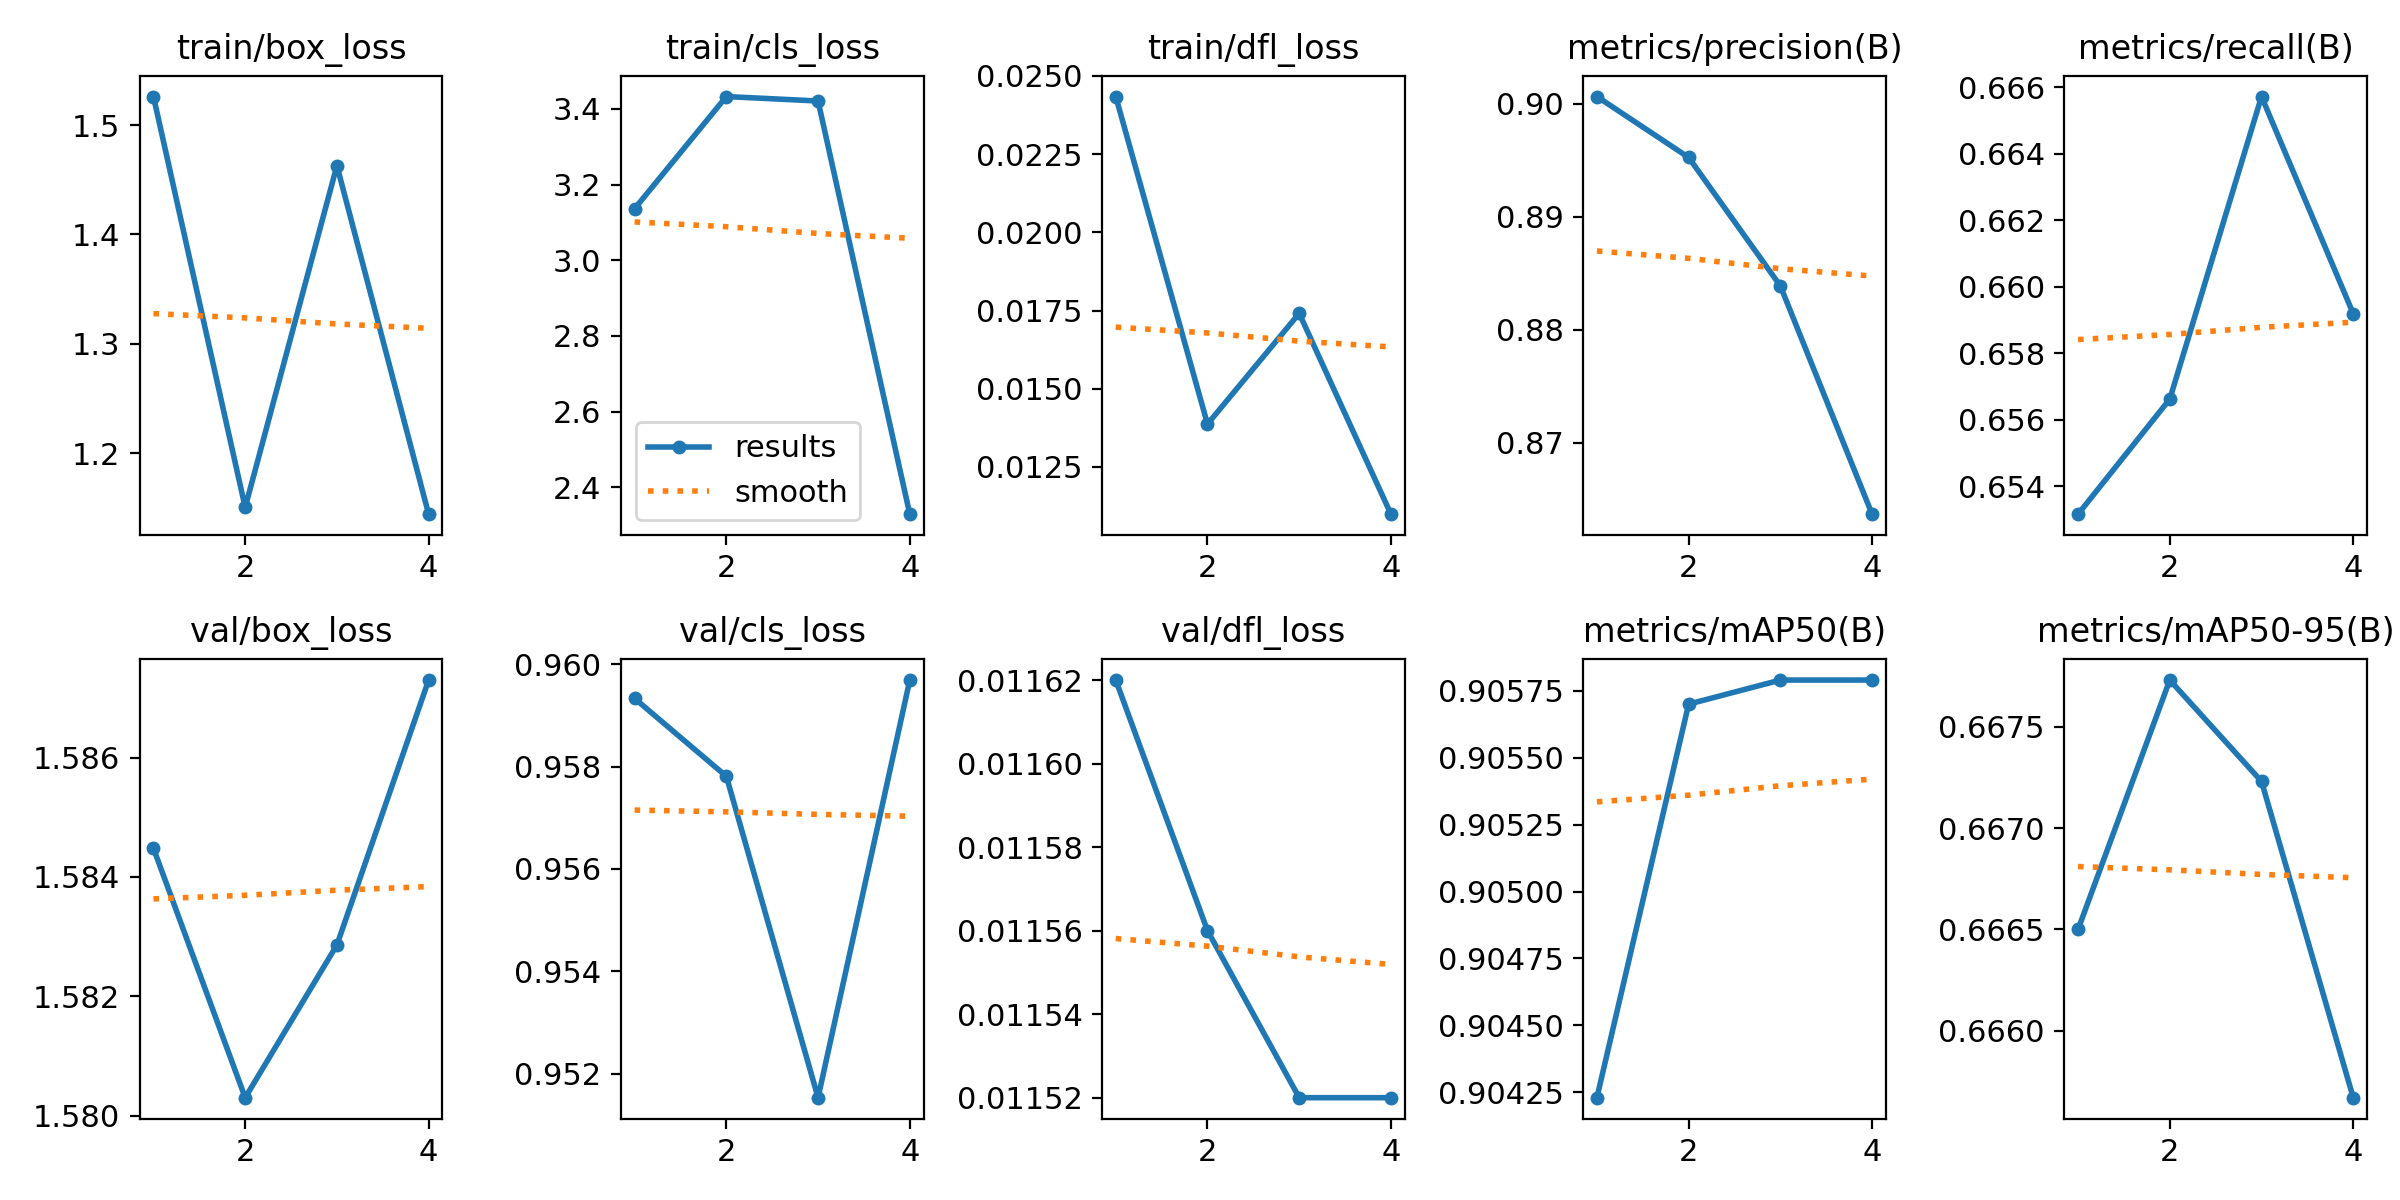

In [10]:
print("Métricas de Desempenho (Loss e mAP)")
display(Image(filename='runs/detect/train/results.png', width=1000))

# Matriz de Confusão
Analisando TP, FP, FN, TN

Matriz de Confusão


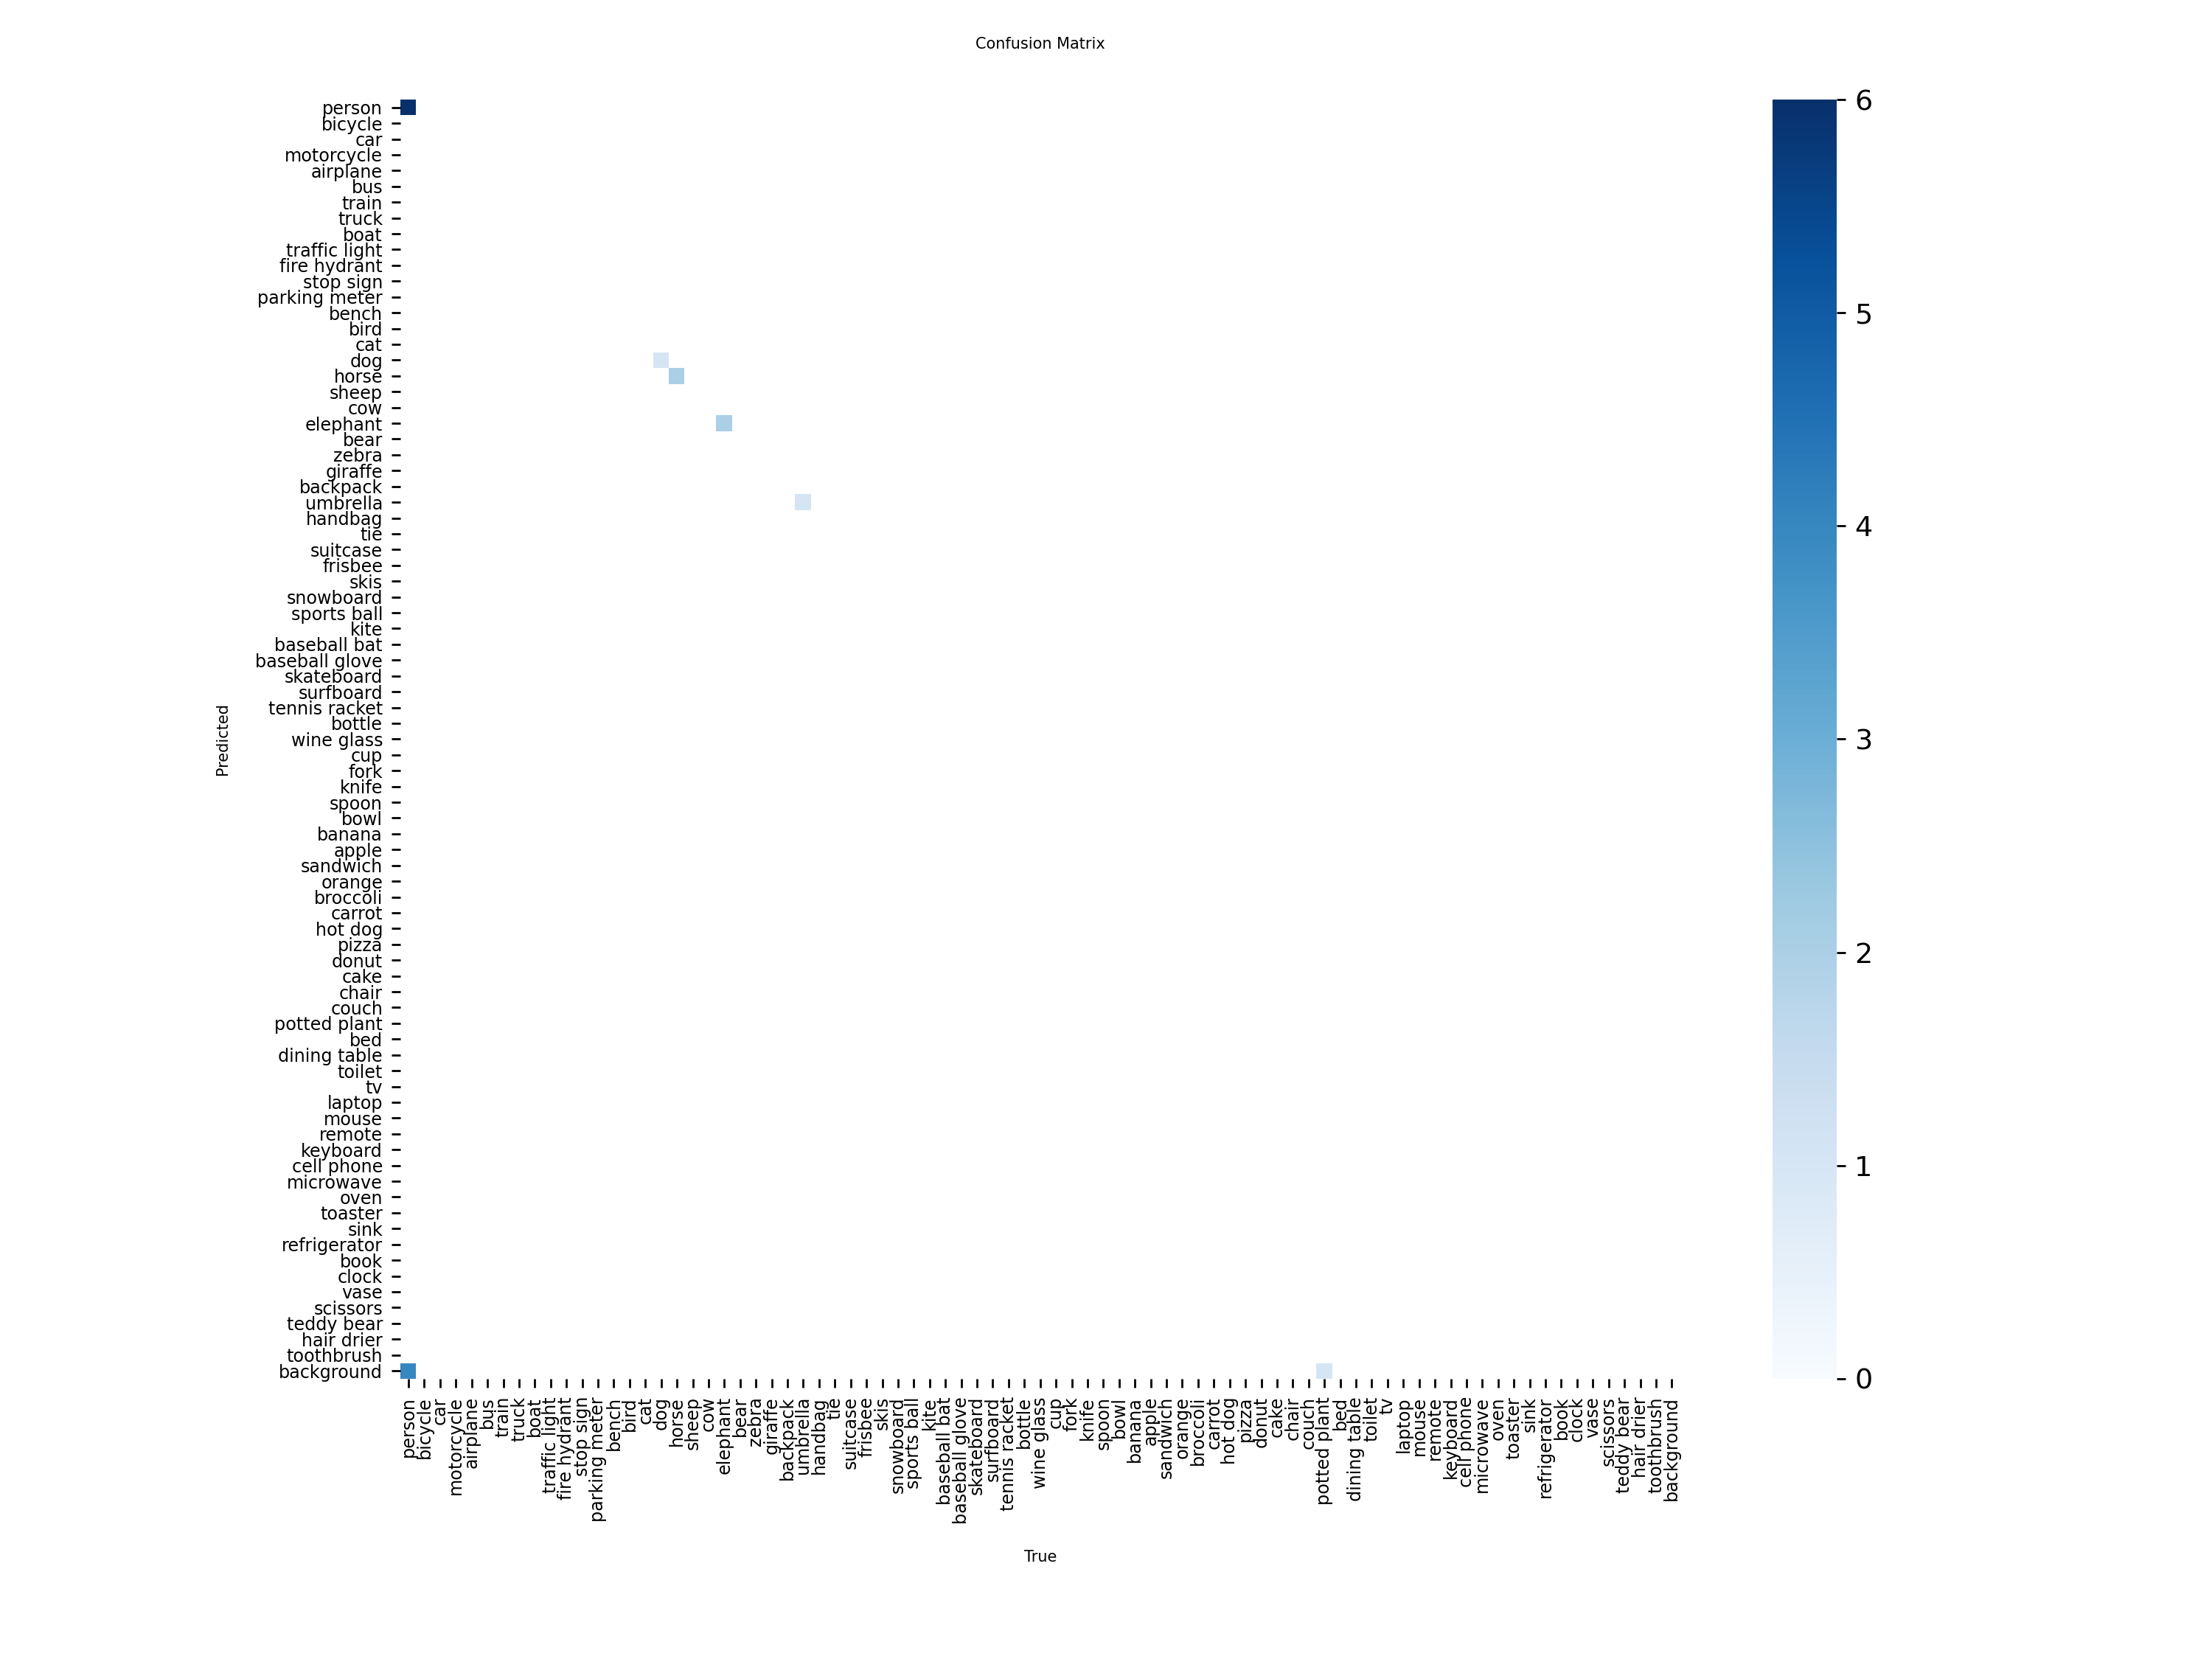

In [7]:
print("Matriz de Confusão")
display(Image(filename='runs/detect/train/confusion_matrix.png', width=800))

# F1 Score

O F1-Score é a métrica que diz se o seu modelo atingiu o ponto de equilíbrio perfeito entre não ter alucinações (falsos positivos) e não ser cego (falsos negativos). No gráfico BoxF1_curve, o topo da "montanha" mostra exatamente qual nível de Confiança (Confidence) você deve configurar no código para ter a melhor IA possível!

Curva F1-Score


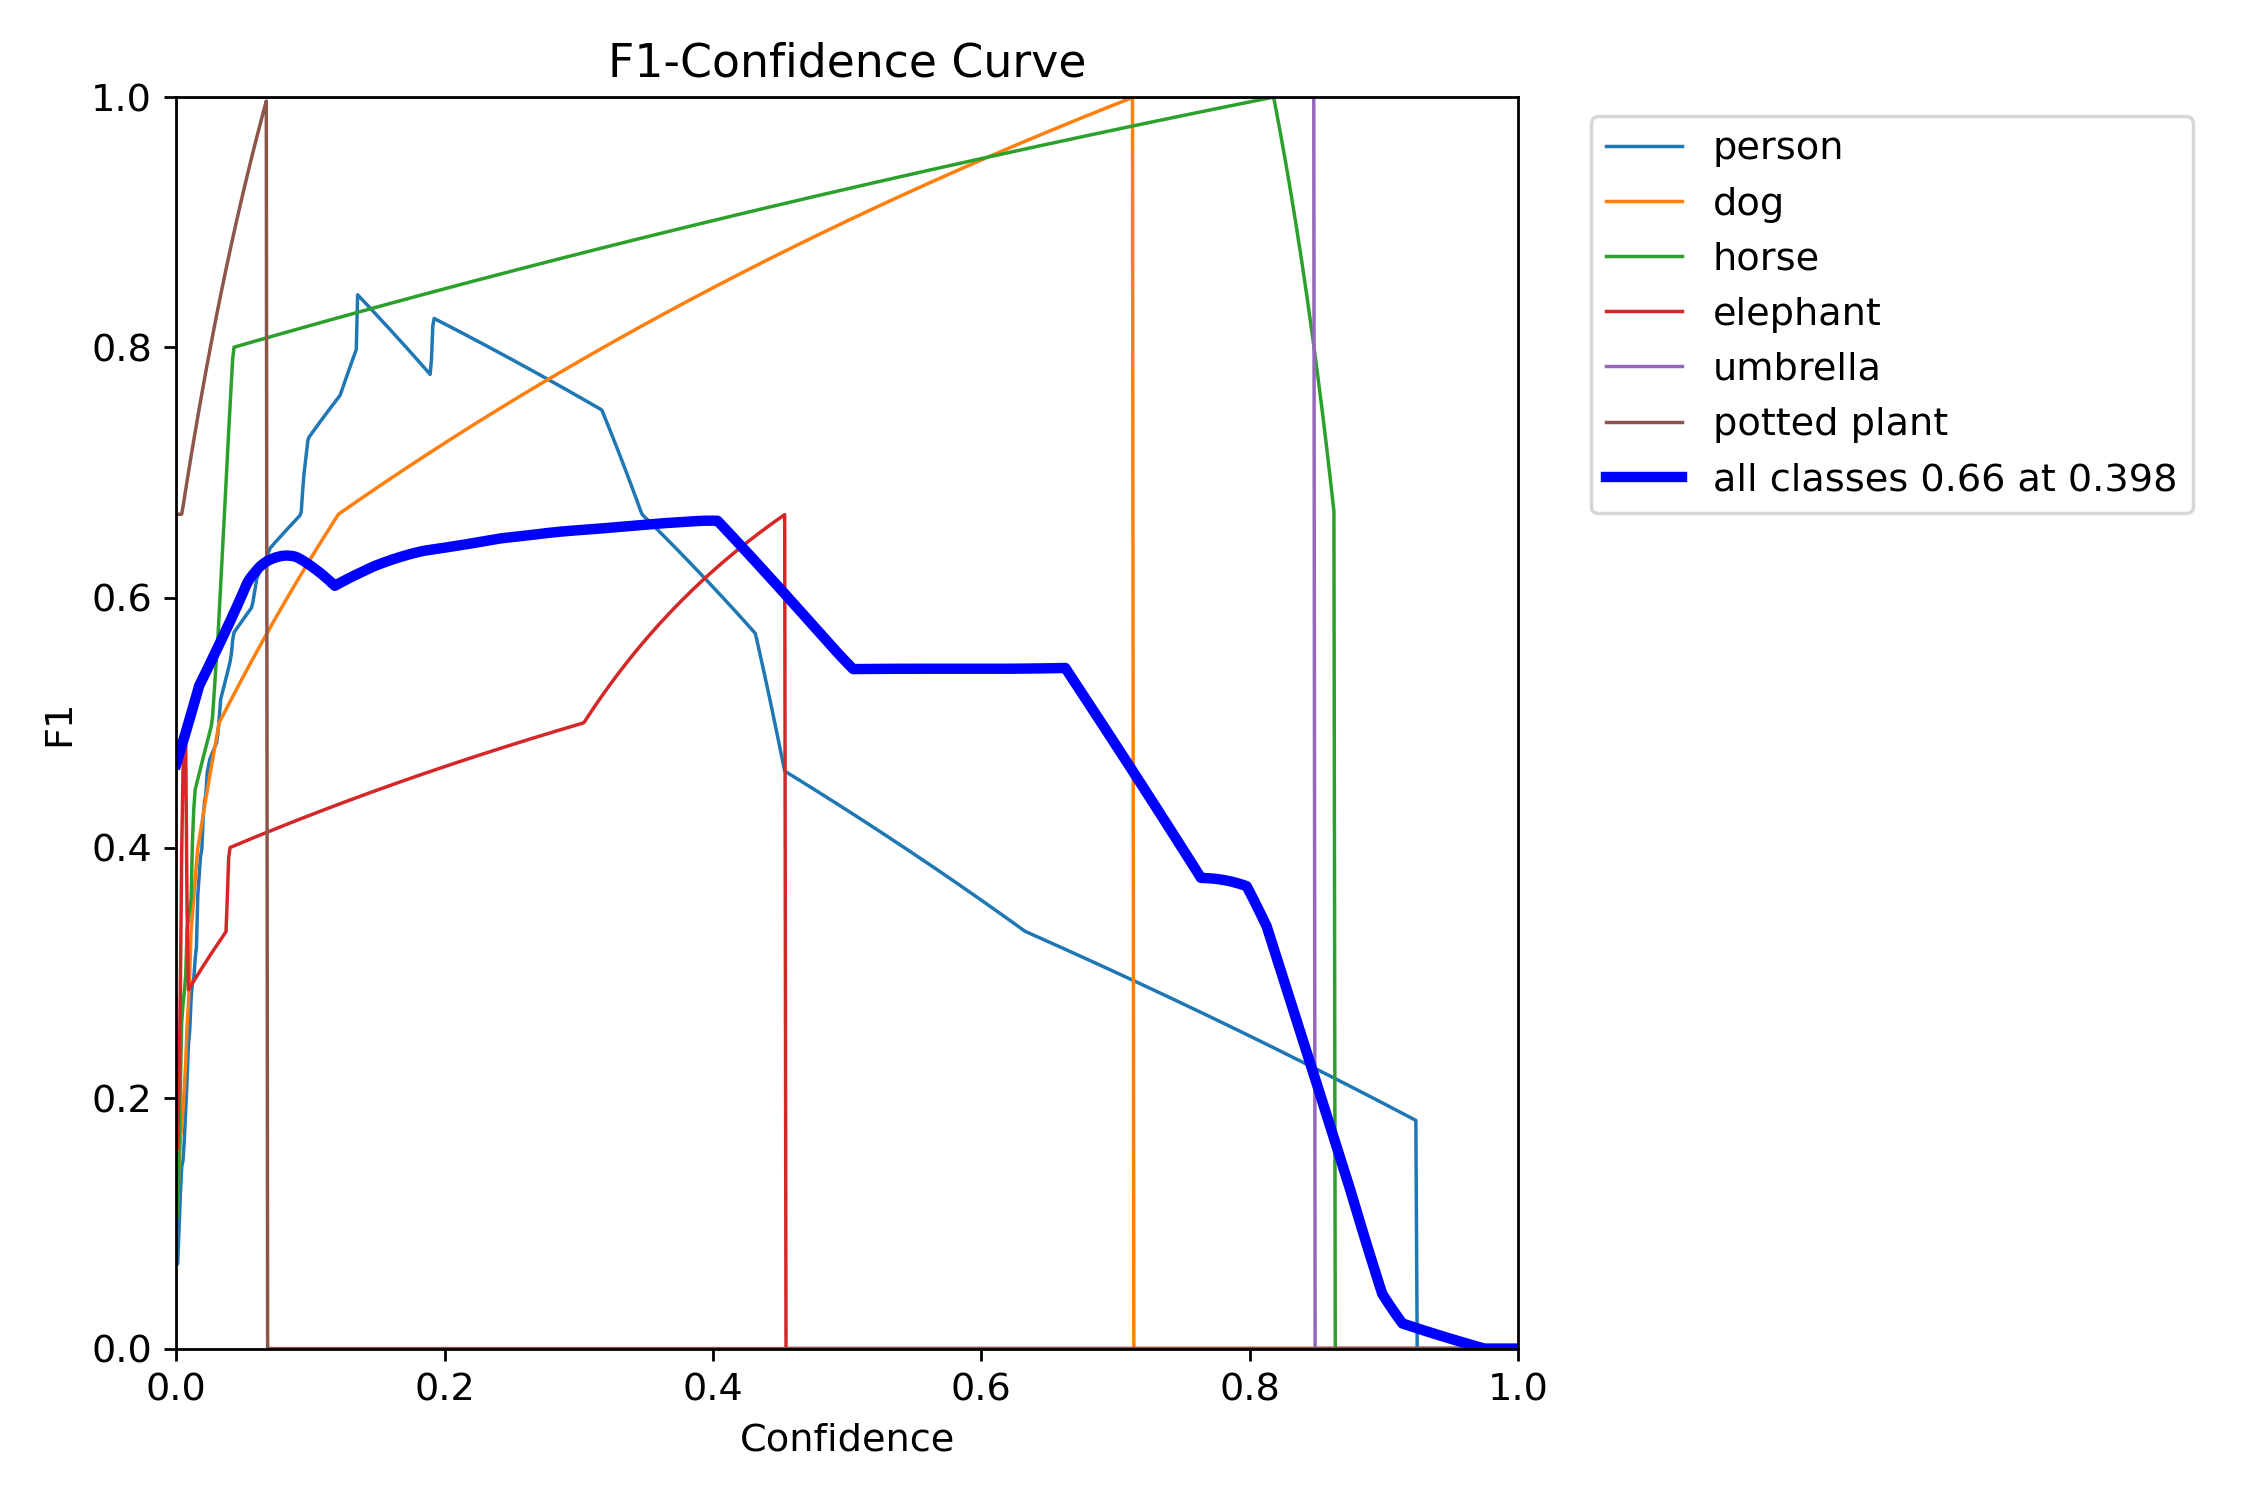

In [9]:
print("Curva F1-Score")
display(Image(filename='runs/detect/train/BoxF1_curve.png', width=800))